In [2]:
!pip install seaborn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
data = {
    'area_sqft': [850, 900, 950, 1000, 1100, 1200, 1250, 1300, 1400, 1500,
                  1550, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2400, 2500],

    'bedrooms': [2, 2, 2, 2, 3, 3, 3, 3, 3, 3,
                 3, 3, 3, 4, 4, 4, 4, 4, 4, 5],

    'bathrooms': [1, 1, 2, 2, 2, 2, 2, 2, 2, 3,
                  3, 3, 3, 3, 3, 3, 4, 4, 4, 4],

    'stories': [1, 1, 1, 2, 2, 2, 2, 2, 2, 2,
                2, 2, 2, 2, 2, 2, 2, 2, 2, 2],

    'parking': [0, 1, 1, 1, 1, 1, 2, 1, 2, 2,
                2, 2, 2, 2, 2, 2, 2, 2, 2, 2],

    'age_years': [15, 12, 10, 9, 8, 7, 6, 5, 5, 4,
                  4, 3, 3, 2, 2, 2, 1, 1, 1, 0],

    'price_lakhs': [38, 42, 45, 52, 60, 66, 70, 74, 82, 90,
                    94, 99, 108, 118, 126, 135, 145, 155, 175, 190]
}

In [5]:
df = pd.DataFrame(data)

df.head()

,area_sqft,bedrooms,bathrooms,stories,parking,age_years,price_lakhs
0,850,2,1,1,0,15,38
1,900,2,1,1,1,12,42
2,950,2,2,1,1,10,45
3,1000,2,2,2,1,9,52
4,1100,3,2,2,1,8,60


In [6]:
df.shape

(20, 7)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   area_sqft    20 non-null     int64
 1   bedrooms     20 non-null     int64
 2   bathrooms    20 non-null     int64
 3   stories      20 non-null     int64
 4   parking      20 non-null     int64
 5   age_years    20 non-null     int64
 6   price_lakhs  20 non-null     int64
dtypes: int64(7)
memory usage: 1.2 KB


In [8]:
df.describe()

,area_sqft,bedrooms,bathrooms,stories,parking,age_years,price_lakhs
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,1560.000000,3.200000,2.650000,1.850000,1.600000,5.000000,98.200000
std,504.610324,0.833509,0.933302,0.366348,0.598243,4.065257,44.914656
min,850.000000,2.000000,1.000000,1.000000,0.000000,0.000000,38.000000
25%,1175.000000,3.000000,2.000000,2.000000,1.000000,2.000000,64.500000
50%,1525.000000,3.000000,3.000000,2.000000,2.000000,4.000000,92.000000
75%,1925.000000,4.000000,3.000000,2.000000,2.000000,7.250000,128.250000
max,2500.000000,5.000000,4.000000,2.000000,2.000000,15.000000,190.000000


In [9]:
df.isnull().sum()

area_sqft      0
bedrooms       0
bathrooms      0
stories        0
parking        0
age_years      0
price_lakhs    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

Area vs Price

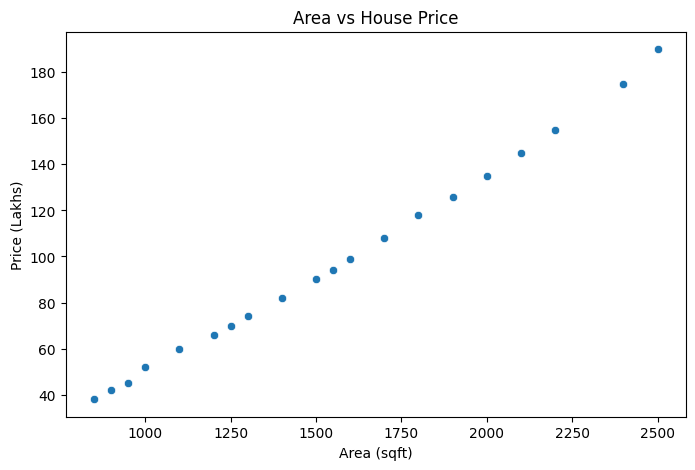

In [12]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='area_sqft',
    y='price_lakhs'
)

plt.title('Area vs House Price')
plt.xlabel('Area (sqft)')
plt.ylabel('Price (Lakhs)')

plt.show()

Bedrooms vs Price

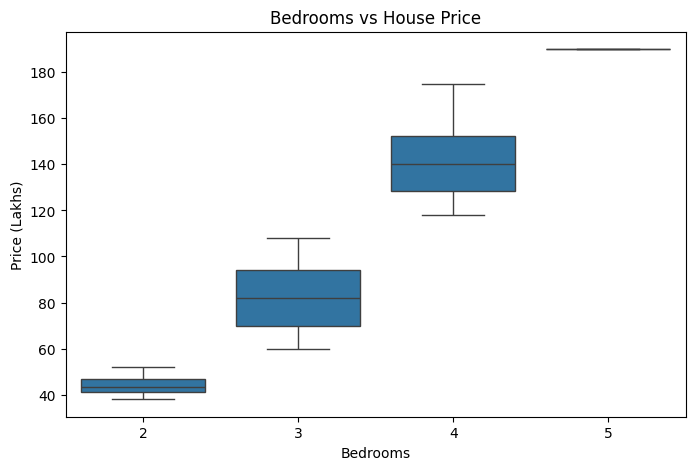

In [13]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='bedrooms',
    y='price_lakhs'
)

plt.title('Bedrooms vs House Price')
plt.xlabel('Bedrooms')
plt.ylabel('Price (Lakhs)')

plt.show()

Correlation Matrix

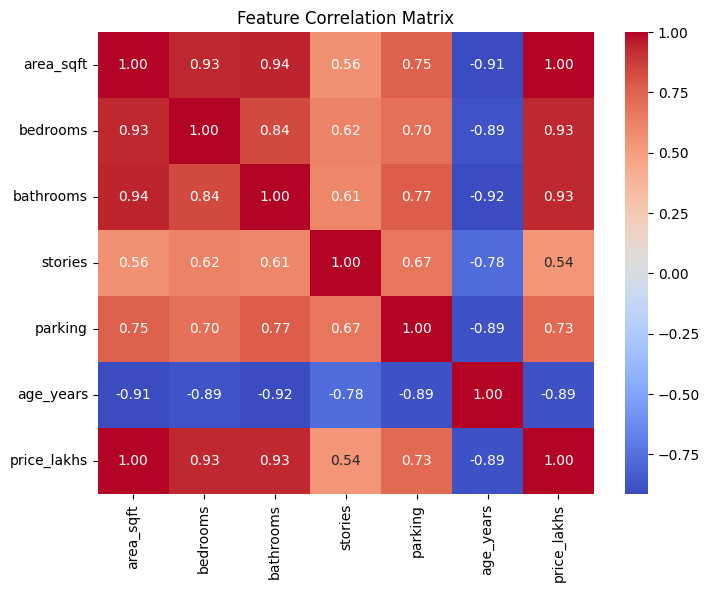

In [14]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Feature Correlation Matrix')

plt.show()

Create X and y

In [15]:
X = df[
    [
        'area_sqft',
        'bedrooms',
        'bathrooms',
        'stories',
        'parking',
        'age_years'
    ]
]

y = df['price_lakhs']

Train/Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

Create the Model

In [17]:
model = LinearRegression()

Train the Model

In [18]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Inspect the Model

In [19]:
print('Intercept:', model.intercept_)

print('\nCoefficients:')

for feature, coefficient in zip(X.columns, model.coef_):
    print(f'{feature}: {coefficient:.4f}')

Intercept: -84.54860558542131

Coefficients:
area_sqft: 0.1028
bedrooms: 2.3613
bathrooms: -0.1243
stories: 2.7813
parking: -1.2636
age_years: 2.5878


Make Predictions

In [20]:
y_pred = model.predict(X_test)

In [21]:
results = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

results

,Actual Price,Predicted Price
0,38,49.044637
1,155,156.227250
2,135,138.375221
3,42,45.158771


Evaluate the model

In [22]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

In [23]:
print(f'MAE: {mae:.2f} lakhs')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f} lakhs')
print(f'R² Score: {r2:.2f}')

MAE: 4.70 lakhs
MSE: 36.22
RMSE: 6.02 lakhs
R² Score: 0.99


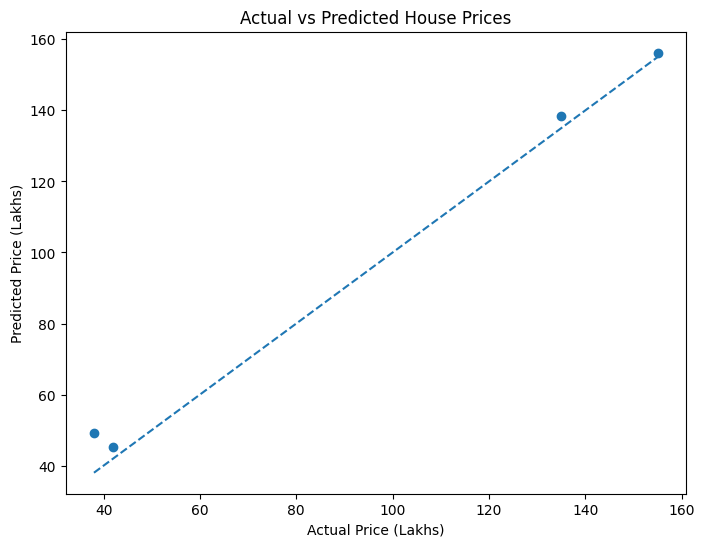

In [24]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel('Actual Price (Lakhs)')
plt.ylabel('Predicted Price (Lakhs)')
plt.title('Actual vs Predicted House Prices')

plt.show()

In [25]:
new_house = pd.DataFrame({
    'area_sqft': [1500],
    'bedrooms': [3],
    'bathrooms': [2],
    'stories': [2],
    'parking': [2],
    'age_years': [3]
})

In [28]:
predicted_price = model.predict(new_house)[0]
print(f'Predicted House Price: ₹{predicted_price:.2f} lakhs')

Predicted House Price: ₹87.32 lakhs
